# Netflix Originals Data Analysis

This report analyzes Netflix Originals data to answer questions about language, genre, IMDb scores, and runtime statistics.  
All analysis is performed in Python using pandas and matplotlib.

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

#load the dataset and fill missing values
df = pd.read_csv('NetflixOriginals.csv', encoding='ISO-8859-1')
df['Language'] = df['Language'].fillna('')

# Create boolean masks for English and multi-language films
is_english_lng = df['Language'].str.contains('English', case=False)
is_multiple_lang = df['Language'].str.contains('/')

# Count English-language films and total films
english_movie_count = is_english_lng.sum()
total_movie_count = len(df)

# Count films with multiple non-English languages and single-language, non-English films
multi_non_english_count = df[is_multiple_lang & ~is_english_lng].shape[0]
single_non_english_count = total_movie_count - english_movie_count - multi_non_english_count

# Get top and bottom 5 films by IMDb score
top_5_imdb_scores = df[['Title', 'IMDB Score']].head()
bottom_5_imdb_scores = df[['Title', 'IMDB Score']].tail()

# IMDb score stats
imdb_score_mean = df['IMDB Score'].mean()
imdb_score_std = df['IMDB Score'].std()

# Runtime stats
runtime_mean = df['Runtime'].mean()
runtime_std = df['Runtime'].std()
runtime_median = df['Runtime'].median()
runtime_iqr = df['Runtime'].quantile(0.75) - df['Runtime'].quantile(0.25)

# Find the film with the longest runtime
longest_runtime_row = df.nlargest(1, 'Runtime')[['Title', 'Runtime']].iloc[0]

# Calculate correlation coefficient between runtime and IMDb score
correlation_coefficient = df['Runtime'].corr(df['IMDB Score'])

#english_percentage from all movies
english_precentage = english_movie_count / total_movie_count * 100

#english films non english single langugage films ratio
english_to_non_english_ratio_signle_lang_ratio = english_movie_count / single_non_english_count

#mutiple_language_films_to_films_ratio
mutiple_language_films_to_films_ratio = round(is_multiple_lang.sum() / total_movie_count, 2)

#films with multiple languages
multi_lang_genres = df[is_multiple_lang]['Genre'].value_counts()


## Table of Contents
- [Q1: What percentage of all films are primarily in English?](#q1-what-percentage-of-all-films-are-primarily-in-english)
- [Q2: What is the ratio of English-language films to single-language, non-English films?](#q2-what-is-the-ratio-of-english-language-films-to-single-language-non-english-films)
- [Q3: What percentage of films are in multiple languages?](#q3-what-percentage-of-films-are-in-multiple-languages)
- [Q4: Which genres are most common among films with multiple languages?](#q4-which-genres-are-most-common-among-films-with-multiple-languages)
- [Q5: How are IMDb scores distributed?](#q5-how-are-imdb-scores-distributed)
- [Q6: Which films have the highest and lowest IMDb scores?](#q6-which-films-have-the-highest-and-lowest-imdb-scores)
- [Q7: Does the runtime distribution suggest the mean and standard deviation accurately represent the data?](#q7-does-the-runtime-distribution-suggest-the-mean-and-standard-deviation-accurately-represent-the-data)
- [Q8: What alternative statistics are more robust for skewed runtime data?](#q8-what-alternative-statistics-are-more-robust-for-skewed-runtime-data)
- [Q9: What are the median and interquartile range (IQR) of the film runtimes?](#q9-what-are-the-median-and-interquartile-range-iqr-of-the-film-runtimes)
- [Q10: Which film has the longest runtime and what is its duration?](#q10-which-film-has-the-longest-runtime-and-what-is-its-duration)
- [Q11: Given a correlation coefficient of 0.92, does the scatterplot support such a strong linear relationship?](#q11-given-a-correlation-coefficient-of-092-does-the-scatterplot-support-such-a-strong-linear-relationship)
- [Q12: What does a correlation coefficient of 0.92 indicate about the relationship between runtime and IMDb score?](#q12-what-does-a-correlation-coefficient-of-092-indicate-about-the-relationship-between-runtime-and-imdb-score)
- [Q13: What is the actual correlation coefficient between runtime and IMDb score, and what does it mean?](#q13-what-is-the-actual-correlation-coefficient-between-runtime-and-imdb-score-and-what-does-it-mean)

## Q1: What percentage of all films are primarily in English?

**Answer:**  

About **72.26%** of all films are primarily in English.

## Q2: What is the ratio of English-language films to single-language, non-English films?

**Answer:**

The ratio of English-language films to single-language, non-English films is **2.63**.

## Q3: What is the ratio of multiple languages to all films?  

**Answer:**  

The ratio of films with multiple languages to all films is **0.04 (or 4%)**.
This means that only about 4% of Netflix Originals are produced in more than one language.

## Q4: Which genres are most common among films with multiple languages?  

**Answer:**  

The most common genre among films with multiple languages is **Documentary** with 17 films.  
Other genres and their counts are shown above.

## IMDb Score distribution histogram Analysis

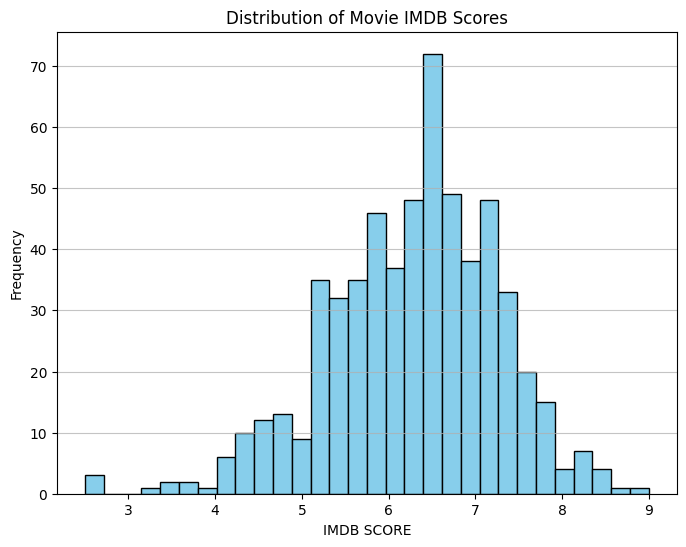

In [119]:
plt.figure(figsize=(8,6))
plt.hist(df['IMDB Score'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('IMDB SCORE')
plt.ylabel('Frequency')
plt.title('Distribution of Movie IMDB Scores')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Q5: How are IMDb scores distributed?  

**Answer:**  

The mean of the IMDb score is **6.27** with a standard deviation of **0.98**.
The histogram shows that most scores cluster around the mean, suggesting an approximately normal distribution.
This indicates that the mean is a reliable measure of the average IMDb score for these films.
With a standard deviation of 0.98, we can infer that the majority of films have IMDb scores between about 5.3 and 7.3.

## Q6: Which films have the highest and lowest IMDb scores?

**Answer:**  

 Top 5 IMDB scores:

| Title                                      | Genre         | Premiere           | Runtime | IMDB Score | Language   |
|---------------------------------------------|---------------|--------------------|---------|------------|------------|
| David Attenborough: A Life on Our Planet    | Documentary   | October 4, 2020    | 83      | 9.0        | English    |
| Emicida: AmarElo - It's All For Yesterday   | Documentary   | December 8, 2020   | 89      | 8.6        | Portuguese |
| Springsteen on Broadway                     | One-man show  | December 16, 2018  | 153     | 8.5        | English    |
| Ben Platt: Live from Radio City Music Hall  | Concert Film  | May 20, 2020       | 85      | 8.4        | English    |
| Taylor Swift: Reputation Stadium Tour       | Concert Film  | December 31, 2018  | 125     | 8.4        | English    |

Bottom 5 IMDB scores:

| Title           | Genre                  | Premiere           | Runtime | IMDB Score | Language         |
|-----------------|------------------------|--------------------|---------|------------|------------------|
| Enter the Anime | Documentary            | August 5, 2019     | 58      | 2.5        | English/Japanese |
| Dark Forces     | Thriller               | August 21, 2020    | 81      | 2.6        | Spanish          |
| The App         | Science fiction/Drama  | December 26, 2019  | 79      | 2.6        | Italian          |
| The Open House  | Horror thriller        | January 19, 2018   | 94      | 3.2        | English          |
| Kaali Khuhi     | Mystery                | October 30, 2020   | 90      | 3.4        | Hindi            |

## Movie Runtime distribution histogram Analysis

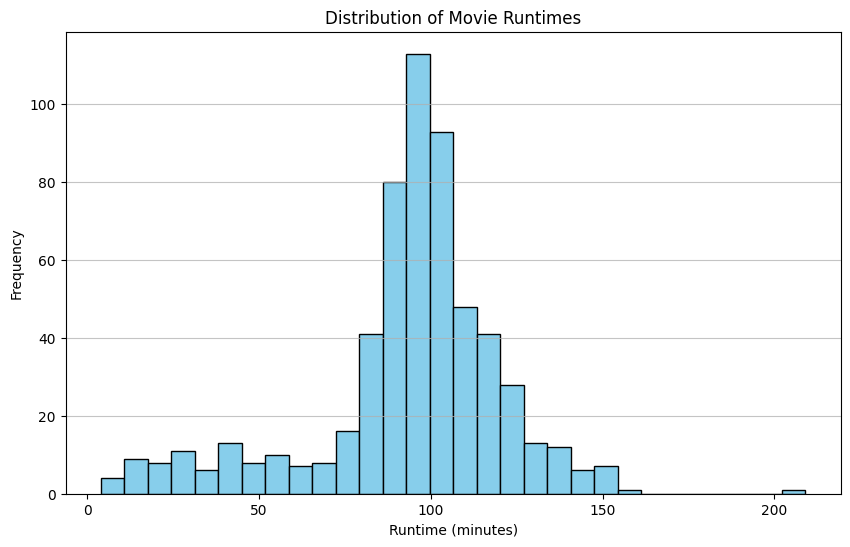

In [120]:
plt.figure(figsize=(10,6))
plt.hist(df['Runtime'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Movie Runtimes')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Q7: Does the runtime distribution suggest the mean and standard deviation accurately represent the data?  

**Answer:**  

The distribution is left-skewed, with most scores clustered on the left and fewer high scores in the middle. 
This skewness can distort the mean, making it less representative of the typical value.
Additionally, there is a single high runtime above 200 minutes, which appears to be an outlier and may further affect the mean.

## Q8: What alternative statistics are more robust for skewed runtime data?

**Answer:**  

The **median** and the **IQR** will be more accurate in this case, as they are less affected by outliers and skewed distributions.

## Q9: What are the median and interquartile range (IQR) of the film runtimes?  

**Answer:**  

The median runtime is 97 minutes, and the IQR is 22 minutes.
The mean has a typical runtime around 90 minutes, whereas the median is around 100.
The low IQR that indicates that half the values are close to the median,
it can be which implies that the left skew is more influential on the mean than the high outlier.

## Q10: Which film has the longest runtime and what is its duration?  

**Answer:**  

The film with the longest runtime is **'The Irishman'** with a runtime of **209 minutes**.

## IMDb Score distribution histogram Analysis

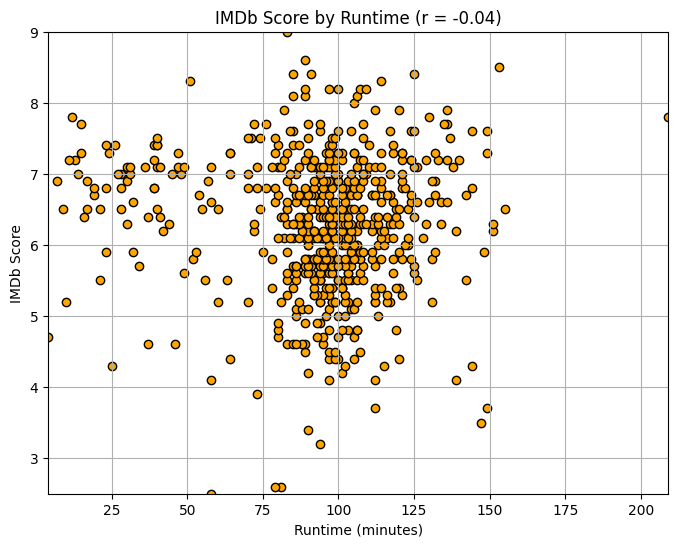

In [121]:
plt.figure(figsize=(8,6))
plt.scatter(df['Runtime'], df['IMDB Score'], color='orange', edgecolor='black')
plt.title(f"IMDb Score by Runtime (r = {correlation_coefficient:.2f})")
plt.xlabel("Runtime (minutes)")
plt.ylabel("IMDb Score")
plt.xlim(df['Runtime'].min(), df['Runtime'].max())
plt.ylim(df['IMDB Score'].min(), df['IMDB Score'].max())
plt.grid(True)
plt.show()

## Q11: Given a correlation coefficient of 0.92, does the scatterplot support such a strong linear relationship?  

**Answer:**  

The plot shows a concentration of points in the middle, **which doesn't fit** the coefficient of 0.92,
which inferes a strong linear relationship. 

## Q12: What does a correlation coefficient of 0.92 indicate about the relationship between runtime and IMDb score?  

**Answer:**  

It indicates a **strong positive relationship** between runtime and IMDb score, meaning that the longer the runtime the higher the score and vice versa.

## Q13: What is the actual correlation coefficient between runtime and IMDb score, and what does it mean?

**Answer:**

The true correlation coefficient between runtime and IMDb score is **-0.04**.

This indicates a **weak negative relationship** between runtime and IMDb score, meaning that the longer the runtime, the lower the score. This is in contrast to the previously assumed strong positive relationship.